# Sensitivity tests on [Ce/Mg]-age trends

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from scipy import stats

import paths
from colormaps import paultol
from utils import binned_quantiles, get_bin_centers
from plotting import ONE_COLUMN_WIDTH, TWO_COLUMN_WIDTH, colored_text_legend

plt.style.use(paths.styles / 'notebook.mplstyle')

In [42]:
full_sample = pd.read_csv(paths.data / 'MWM' / 'sample.csv')
full_sample

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
0,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,8.590056,0.0,-0.263113,0.010890,-0.013271,0.013271,0.260731,0.274003,True,False
1,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,9.153462,0.0,-0.241018,0.079030,0.003839,-0.003839,0.323887,0.320048,True,False
2,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,10.254416,0.0,-0.112523,0.228345,-0.020530,0.020530,0.320339,0.340869,True,False
3,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,9.035937,0.0,0.061913,0.190950,0.048523,-0.048523,0.177560,0.129037,True,False
4,54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,...,14.852359,0.0,-0.182748,0.012715,0.005658,-0.005658,0.201122,0.195464,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120758,129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,...,7.758100,0.0,-0.059793,0.246831,0.047802,-0.047802,0.354426,0.306624,True,False
120759,129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,...,10.770966,0.0,-0.523929,-0.496442,-0.060767,0.060767,-0.033280,0.027487,True,False
120760,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,4.912325,0.0,-0.363648,-0.118817,-0.011611,0.011611,0.233220,0.244831,True,False
120761,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,9.945469,0.0,-0.176592,0.063355,-0.014382,0.014382,0.225565,0.239947,True,False


## Local abundance trends

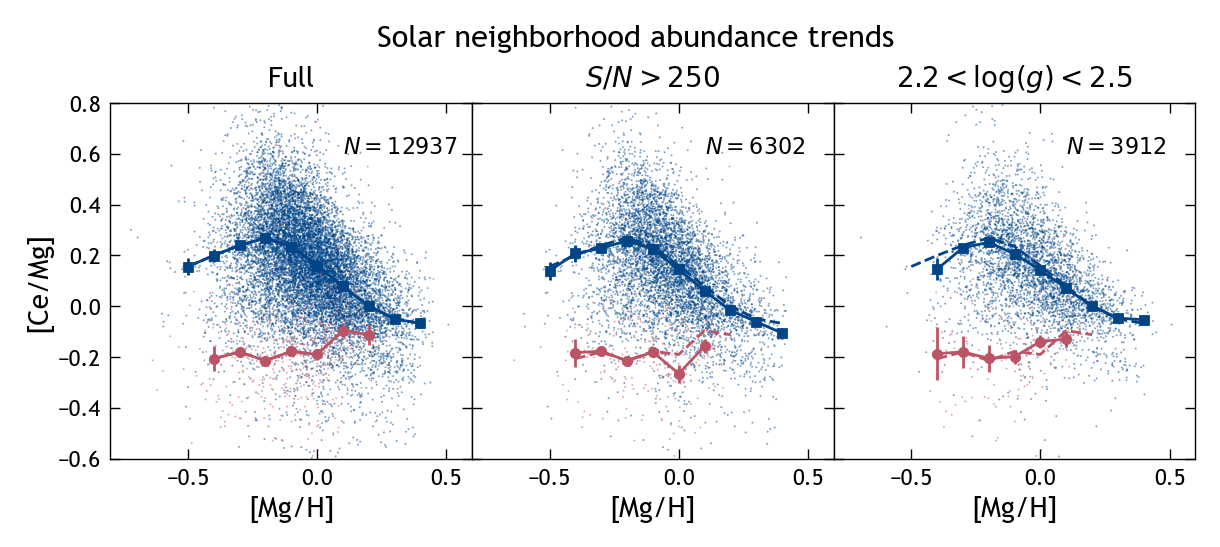

In [116]:
local_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
local_highsn = local_sample[local_sample['snr'] > 250]
local_lowlogg = local_sample[local_sample['logg'] < 2.5]
local_rc = local_sample[(local_sample['logg'] < 2.5) & (local_sample['logg'] > 2.2)]

mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
local_low_alpha_medians = binned_quantiles(
    local_sample[local_sample['low_alpha']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
local_high_alpha_medians = binned_quantiles(
    local_sample[local_sample['high_alpha']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

high_alpha_color = paultol.highcontrast.colors[2]
low_alpha_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 3, 
    figsize=(TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Full', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$']
for i, df in enumerate([local_sample, local_highsn, local_rc]):
    # Plot individual stars
    df_low_alpha = df[df['low_alpha']]
    axs[i].scatter(
        df_low_alpha['mg_h'], df_low_alpha['ce_mg_corr'],
        c=low_alpha_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_high_alpha = df[df['high_alpha']]
    axs[i].scatter(
        df_high_alpha['mg_h'], df_high_alpha['ce_mg_corr'],
        c=high_alpha_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_low_alpha, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=low_alpha_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_high_alpha, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=high_alpha_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *local_low_alpha_medians, 
        linestyle='--', color=low_alpha_color, label='High-Ia',
    )
    axs[i].plot(
        *local_high_alpha_medians, 
        linestyle='--', color=high_alpha_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.6, 0.8))
fig.suptitle('Solar neighborhood abundance trends', y=1.05)
plt.show()

## Inner galaxy abundance trends

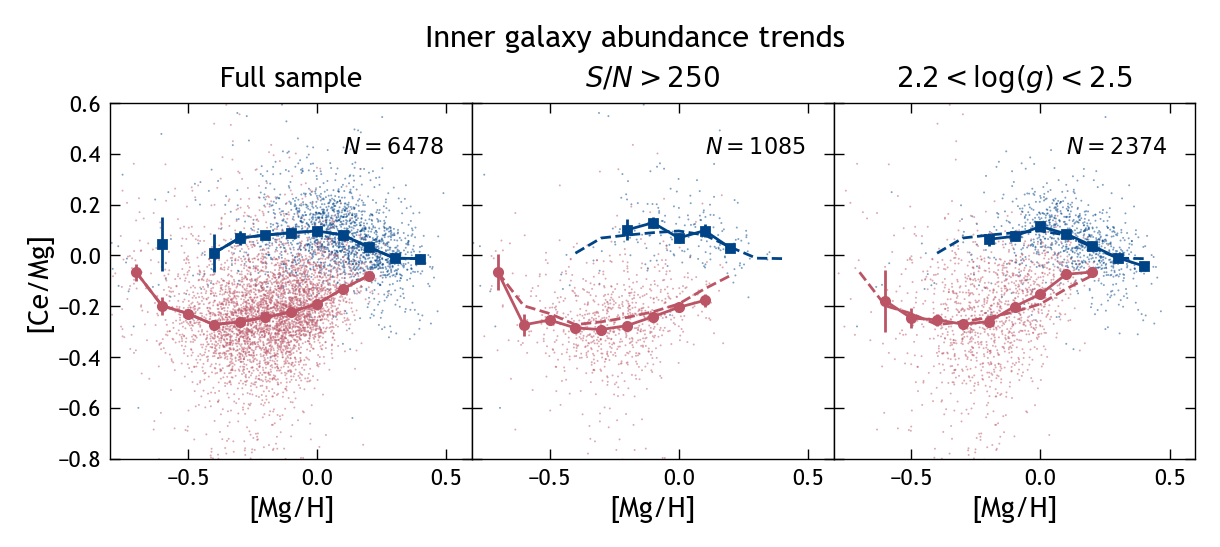

In [122]:
inner_sample = full_sample[(full_sample['Rg'] >= 3) & (full_sample['Rg'] < 5) & (full_sample['z_max'] < 2)]
inner_highsn = inner_sample[inner_sample['snr'] > 250]
inner_lowlogg = inner_sample[inner_sample['logg'] < 2.5]
inner_rc = inner_sample[(inner_sample['logg'] < 2.5) & (inner_sample['logg'] > 2.2)]

mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
inner_low_alpha_medians = binned_quantiles(
    inner_sample[inner_sample['low_alpha']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
inner_high_alpha_medians = binned_quantiles(
    inner_sample[inner_sample['high_alpha']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

high_alpha_color = paultol.highcontrast.colors[2]
low_alpha_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 3, 
    figsize=(TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Full sample', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$']
for i, df in enumerate([inner_sample, inner_highsn, inner_rc]):
    # Plot individual stars
    df_low_alpha = df[df['low_alpha']]
    axs[i].scatter(
        df_low_alpha['mg_h'], df_low_alpha['ce_mg_corr'],
        c=low_alpha_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_high_alpha = df[df['high_alpha']]
    axs[i].scatter(
        df_high_alpha['mg_h'], df_high_alpha['ce_mg_corr'],
        c=high_alpha_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_low_alpha, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=low_alpha_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_high_alpha, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=high_alpha_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *inner_low_alpha_medians, 
        linestyle='--', color=low_alpha_color, label='High-Ia',
    )
    axs[i].plot(
        *inner_high_alpha_medians, 
        linestyle='--', color=high_alpha_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.4, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.8, 0.6))
fig.suptitle('Inner galaxy abundance trends', y=1.05)
plt.show()

## Local metallicity dependence

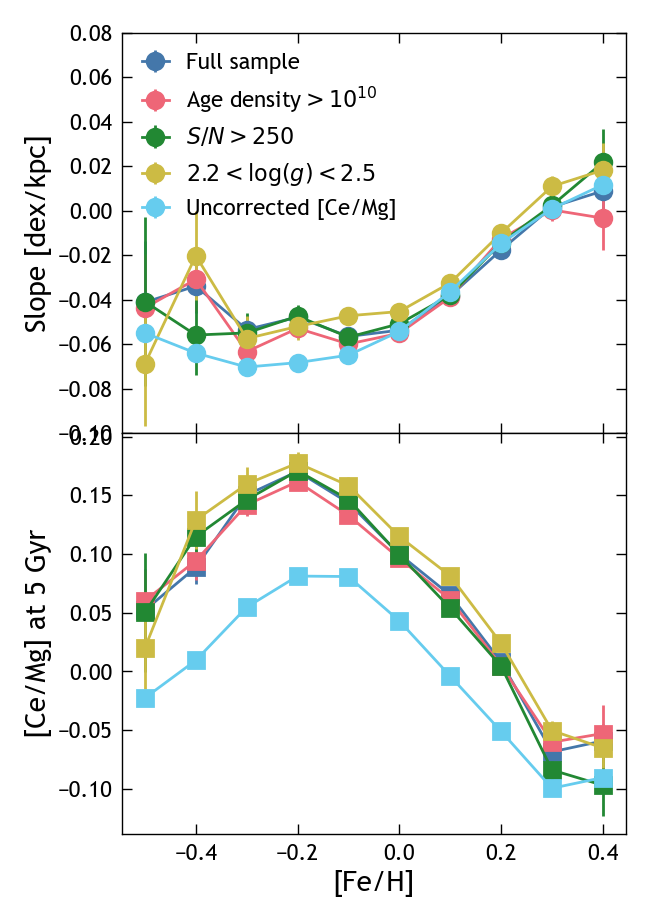

In [80]:
local_ages = local_sample[(local_sample['good_age'])]
local_betterage = local_ages[local_ages['training_density'] > 1e10]
local_highsn_age = local_ages[local_ages['snr'] > 250]
local_lowlogg_age = local_ages[local_ages['logg'] < 2.5]
local_rc_age = local_ages[(local_ages['logg'] < 2.5) & (local_ages['logg'] > 2.2)]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', paultol.bright.colors)
fig, axs = plt.subplots(
    2, 
    figsize=(ONE_COLUMN_WIDTH, 1.6*ONE_COLUMN_WIDTH), 
    sharex=True,
    gridspec_kw={'hspace': 0}
)

met_bins = np.arange(-0.55, 0.46, 0.1)
age_fit_range = (1, 8)
met_col = 'fe_h'
age_delta = 5 # Gyr

ycols = ['ce_mg_corr'] * 4 + ['ce_mg']
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$', 'Uncorrected [Ce/Mg]']
for i, df in enumerate([local_ages, local_betterage, local_highsn_age, local_rc_age, full_sample]):
    df_low_alpha = df[df['low_alpha']]
    # Bin by metallicity and fit linear trend to stars within good age range
    fits = []
    age_arr = np.arange(0, 12.1, 0.1)
    for j in range(len(met_bins)-1):
        met_lim = met_bins[j:j+2]
        met_center = np.mean(met_lim) # mean metallicity of bin
        subset = df_low_alpha[
            (df_low_alpha[met_col] >= met_lim[0]) & 
            (df_low_alpha[met_col] < met_lim[1]) &
            (df_low_alpha['age'] >= age_fit_range[0]) &
            (df_low_alpha['age'] < age_fit_range[1])
        ]
        # Fit linear age trend
        regress = stats.linregress(subset['age'] - age_delta, subset[ycols[i]])
        fits.append(regress)
    # Plot slopes
    slopes = [f.slope for f in fits]
    slope_errs = [f.stderr for f in fits]
    met_bin_centers = get_bin_centers(met_bins)
    axs[0].errorbar(
        met_bin_centers, slopes, yerr=slope_errs, 
        label=labels[i],
        marker='o', linestyle='-', capsize=0
    )
    # Plot intercepts
    intercepts = [f.intercept for f in fits]
    intercept_errs = [f.intercept_stderr for f in fits]
    axs[1].errorbar(
        met_bin_centers, intercepts, yerr=intercept_errs, 
        label=labels[i],
        marker='s', linestyle='-', capsize=0
    )

axs[0].legend()
axs[1].set_xlabel('[Fe/H]')
axs[0].set_ylabel('Slope [dex/kpc]')
axs[1].set_ylabel('[Ce/Mg] at %s Gyr' % age_delta)
axs[0].set_ylim((-0.1, 0.08))
plt.show()

## Global age trends

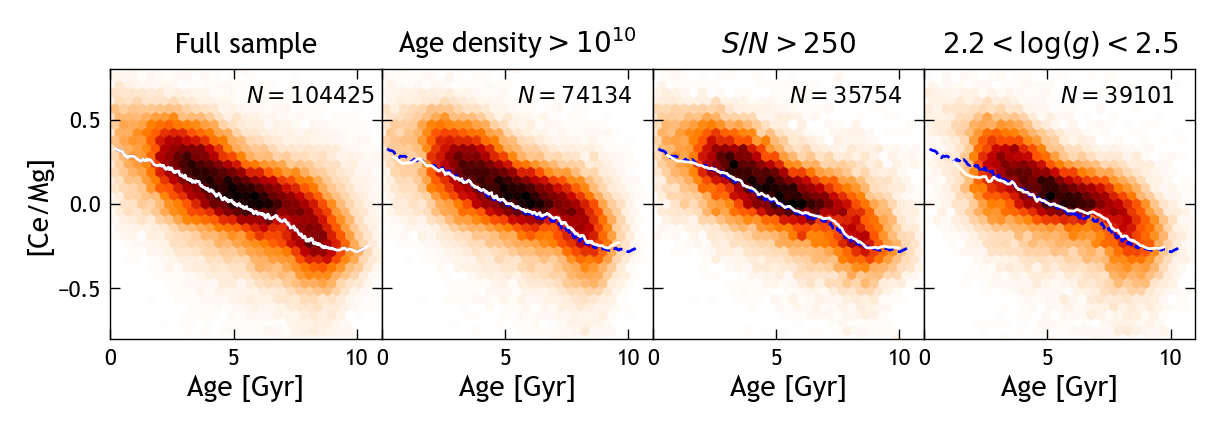

In [101]:
full_ages = full_sample[full_sample['good_age']]
better_ages = full_ages[full_ages['training_density'] > 1e10]
highsn_ages = full_ages[full_ages['snr'] > 250]
lowlogg_ages = full_ages[full_ages['logg'] < 2.5]
rc_ages = full_ages[(full_ages['logg'] < 2.5) & (full_ages['logg'] > 2.2)]

# Compute full sample rolling median trend
full_sorted_ages = full_ages.sort_values('age')[['age', 'ce_mg']]
full_rolling_medians = full_sorted_ages.rolling(
    1000, min_periods=1000, step=250, on='age', center=True
).median()

fig, axs = plt.subplots(
    1, 4, 
    figsize=(TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.8, 0.8)
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$']
for i, df in enumerate([full_ages, better_ages, highsn_ages, rc_ages]):
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg_corr'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        cmap='gist_heat_r',
        gridsize=30,
        linewidths=0.2,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        vmin=0
    )
    # Full sample rolling median for comparison
    axs[i].plot(full_rolling_medians['age'], full_rolling_medians['ce_mg'], 'b--')
    # Rolling median
    sorted_ages = df.sort_values('age')[['age', 'ce_mg']]
    rolling_medians = sorted_ages.rolling(
        1000, min_periods=1000, step=250, on='age', center=True
    ).median()
    axs[i].plot(rolling_medians['age'], rolling_medians['ce_mg'], 'w-')
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
plt.show()

## Global radial dependence

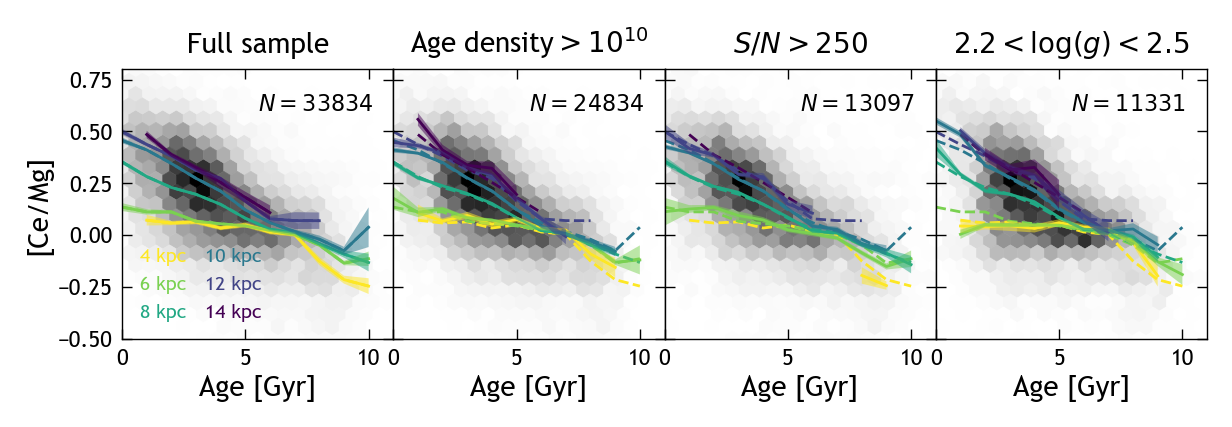

In [123]:
lowz_ages = full_sample[(full_sample['good_age']) & (full_sample['z_max'] < 0.5)]
better_ages = lowz_ages[lowz_ages['training_density'] > 1e10]
highsn_ages = lowz_ages[lowz_ages['snr'] > 250]
lowlogg_ages = lowz_ages[lowz_ages['logg'] < 2.5]
rc_ages = lowz_ages[(lowz_ages['logg'] < 2.5) & (lowz_ages['logg'] > 2.2)]

radius_bin_edges = np.arange(3, 15.1, 2)
age_bin_edges = np.arange(-0.5, 11.6, 1)
radial_cmap = plt.get_cmap('viridis_r')
norm = BoundaryNorm(radius_bin_edges, radial_cmap.N)

fig, axs = plt.subplots(
    1, 4, 
    figsize=(TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.5, 0.8)
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$']
for i, df in enumerate([lowz_ages, better_ages, highsn_ages, rc_ages]):
    # Plot all stars
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg_corr'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        gridsize=20,
        cmap='binary',
        linewidths=0.2,
        mincnt=0,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]]
    )
    # Plot median age trends binned by radius
    for j in range(len(radius_bin_edges)-1):
        radius_bin = radius_bin_edges[j:j+2]
        mean_radius = np.mean(radius_bin)
        df_subset = df[
            (df['Rg'] >= radius_bin[0]) &
            (df['Rg'] < radius_bin[1])
        ]
        age_medians = binned_quantiles(
            df_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *age_medians[:-1], '-', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
            label=f'{int(mean_radius)} kpc'
        )
        axs[i].fill_between(
            age_medians[0],
            age_medians[1]+age_medians[2],
            age_medians[1]-age_medians[2],
            color=radial_cmap(norm(mean_radius)),
            alpha=0.5, edgecolor='none', zorder=2
        )
        # Compare vs median trends in full sample
        full_subset = lowz_ages[
            (lowz_ages['Rg'] >= radius_bin[0]) &
            (lowz_ages['Rg'] < radius_bin[1])
        ]
        full_age_medians = binned_quantiles(
            full_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *full_age_medians[:-1], '--', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
        )
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
colored_text_legend(axs[0], ncols=2, fontsize=7, columnspacing=1)
plt.show()